In [3]:
from zipfile import ZipFile
dat_path='dog-vs-cat.zip'
with ZipFile(dat_path,'r') as zip_ref:
    print('Filename in the archive:')
    for filename in zip_ref.namelist(): 
        print(filename)

In [4]:
# Here I checking dataset's images
from zipfile import ZipFile
from PIL import Image
with ZipFile(dat_path,'r') as archive: 
    with archive.open('dog-cat-full-dataset-master/data/train/dogs/dog.9993.jpg') as file: 
        img=Image.open(file)
        img.show()

In [1]:
# Opening ZipFile and storing data in dataset folder 
import zipfile

with zipfile.ZipFile('dog-vs-cat.zip','r') as zip_ref:
    zip_ref.extractall('dataset')

In [6]:
# We extracting cat from the dataset
import numpy as np 
import pandas as pd
import os

path = r"dataset/dog-cat-full-dataset-master/data/train/cats"

data_cats = []

for img in os.listdir(path):
    data_cats.append({
        "image_path": os.path.join(path, img),
        "label": "cat"
    })



In [7]:
df_cat = pd.DataFrame(data_cats)


In [8]:
# df_cat.sample(5)

In [9]:
df_cat.shape

(10000, 2)

In [10]:
# We extracting dog from the dataset
import pandas as pd
import os

path = r"dataset/dog-cat-full-dataset-master/data/train/dogs/"

data_dogs = []

for img in os.listdir(path):
    data_dogs.append({
        "image_path": os.path.join(path, img),
        "label": "dog"
    })



In [11]:
df_dog=pd.DataFrame(data_dogs)

In [12]:
# df_dog
df_dog.shape

(9989, 2)

In [13]:
# for images, labels in train_data:
#     print(images.shape)
#     print(labels)
#     break

In [14]:
import matplotlib.pyplot as plt 
import numpy as np 
import cv2 
import os
import PIL 
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers 
from tensorflow.keras.models import Sequential

In [15]:
# pip install opencv-python 

In [16]:
# We extracting dog from the dataset
import pandas as pd
import os

data_dir = r"dataset/dog-cat-full-dataset-master/data/train/"

dataset = []

for img in os.listdir(path):
    dataset.append({
        "image_path": os.path.join(path, img)
    })



In [17]:
import pathlib
data_dir=pathlib.Path(data_dir)
data_dir

WindowsPath('dataset/dog-cat-full-dataset-master/data/train')

In [18]:
list(data_dir.glob('*/*.jpg'))[:5]

[WindowsPath('dataset/dog-cat-full-dataset-master/data/train/cats/cat.1.jpg'),
 WindowsPath('dataset/dog-cat-full-dataset-master/data/train/cats/cat.10.jpg'),
 WindowsPath('dataset/dog-cat-full-dataset-master/data/train/cats/cat.100.jpg'),
 WindowsPath('dataset/dog-cat-full-dataset-master/data/train/cats/cat.1000.jpg'),
 WindowsPath('dataset/dog-cat-full-dataset-master/data/train/cats/cat.10000.jpg')]

In [19]:
image_count=len(list(data_dir.glob('*/*.jpg')))
print(image_count)

19989


In [20]:
dogs=list(data_dir.glob('dogs/*'))
dogs[:5]

[WindowsPath('dataset/dog-cat-full-dataset-master/data/train/dogs/dog.1.jpg'),
 WindowsPath('dataset/dog-cat-full-dataset-master/data/train/dogs/dog.10.jpg'),
 WindowsPath('dataset/dog-cat-full-dataset-master/data/train/dogs/dog.100.jpg'),
 WindowsPath('dataset/dog-cat-full-dataset-master/data/train/dogs/dog.1000.jpg'),
 WindowsPath('dataset/dog-cat-full-dataset-master/data/train/dogs/dog.10000.jpg')]

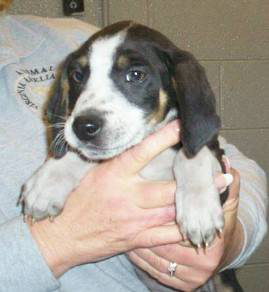

In [21]:
PIL.Image.open(str(dogs[1]))

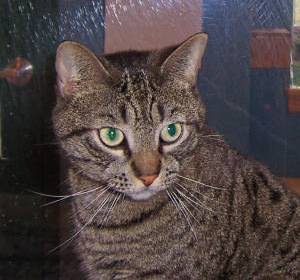

In [22]:
cats=list(data_dir.glob('cats/*'))
PIL.Image.open(str(cats[0]))

In [23]:
Pet_Animals_images_dict={
    'cats':list(data_dir.glob('cats/*')),
    'dogs':list(data_dir.glob('dogs/*')),
    }

In [24]:
Pet_Animal_label_images_dict={
    'cats':0, 
    'dogs':1, 
}

In [25]:
Pet_Animals_images_dict['cats'][:5]

[WindowsPath('dataset/dog-cat-full-dataset-master/data/train/cats/cat.1.jpg'),
 WindowsPath('dataset/dog-cat-full-dataset-master/data/train/cats/cat.10.jpg'),
 WindowsPath('dataset/dog-cat-full-dataset-master/data/train/cats/cat.100.jpg'),
 WindowsPath('dataset/dog-cat-full-dataset-master/data/train/cats/cat.1000.jpg'),
 WindowsPath('dataset/dog-cat-full-dataset-master/data/train/cats/cat.10000.jpg')]

In [26]:
str(Pet_Animals_images_dict['cats'][0])

'dataset\\dog-cat-full-dataset-master\\data\\train\\cats\\cat.1.jpg'

In [27]:
img=cv2.imread(str(Pet_Animals_images_dict['cats'][0]))

In [28]:
img.shape

(280, 300, 3)

In [29]:
cv2.resize(img,(128,128)).shape

(128, 128, 3)

In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   
)

train_generator = datagen.flow_from_directory(
    "dataset/dog-cat-full-dataset-master/data/train",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    "dataset/dog-cat-full-dataset-master/data/train",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 15992 images belonging to 2 classes.
Found 3997 images belonging to 2 classes.


In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, Sequential
import tensorflow as tf

# Model
num_classes = 2 

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu', input_shape=(128,128,3)),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, activation='softmax') 
])

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

model.fit(
    train_generator,
    epochs=4
)

C:\Users\sawsu\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 208s 411ms/step - accuracy: 0.6590 - loss: 0.6065
Epoch 2/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 137ms/step - accuracy: 0.7649 - loss: 0.4907
Epoch 3/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 140ms/step - accuracy: 0.8078 - loss: 0.4189 
Epoch 4/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 95s 190ms/step - accuracy: 0.8390 - loss: 0.3654 


In [32]:
# Builing CNN and train it

In [33]:
model.evaluate(val_generator)

125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 368ms/step - accuracy: 0.8004 - loss: 0.4232


[0.42320674657821655, 0.8003502488136292]

In [34]:
import numpy as np
import cv2
from tensorflow.keras.preprocessing import image


class_names = ['cats', 'dogs'] 

def predict_image(img_path):
    # Load and preprocess
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0         
    img_array = np.expand_dims(img_array, axis=0) 

    # Predict
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0]) * 100

    print(f"Prediction: {predicted_class} ({confidence:.2f}% confident)")
    return predicted_class, confidence


predict_image("../DL_project/WhatsApp Image 2026-03-24 at 6.13.43 PM.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Prediction: dogs (99.75% confident)


('dogs', np.float32(99.746155))

In [35]:
# import os

# test_folder = "path/to/test/images/"

# for filename in os.listdir(test_folder):
#     if filename.endswith(('.jpg', '.jpeg', '.png')):
#         img_path = os.path.join(test_folder, filename)
#         cls, conf = predict_image(img_path)
#         print(f"  File: {filename}")